In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("dataset_phishing.csv")
df.head()


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [3]:
# Remove duplicate URLs
df = df.drop_duplicates(subset=["url"])

# Drop URL column (non-numeric)
df = df.drop(columns=["url"])

df.shape


(11429, 88)

In [4]:
df["status"] = df["status"].map({"legitimate": 0, "phishing": 1})
df["status"].value_counts()


status
0    5715
1    5714
Name: count, dtype: int64

In [5]:
X = df.drop("status", axis=1)
y = df["status"]


In [6]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.935258,0.940655,0.929134,0.934859
1,Decision Tree,0.935258,0.941437,0.928259,0.934802
2,Random Forest,0.959318,0.957317,0.961505,0.959406


In [9]:
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3,
                    scoring="accuracy",
                    n_jobs=-1)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}


In [10]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9601924759405074
Precision: 0.957391304347826
Recall: 0.963254593175853
F1 Score: 0.9603139991277801
ROC-AUC: 0.9922633795884875

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1143
           1       0.96      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



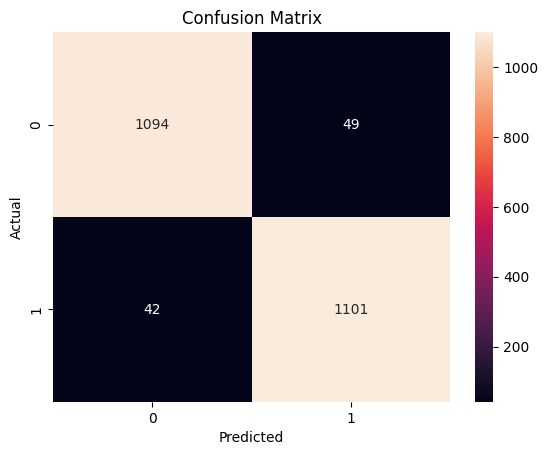

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


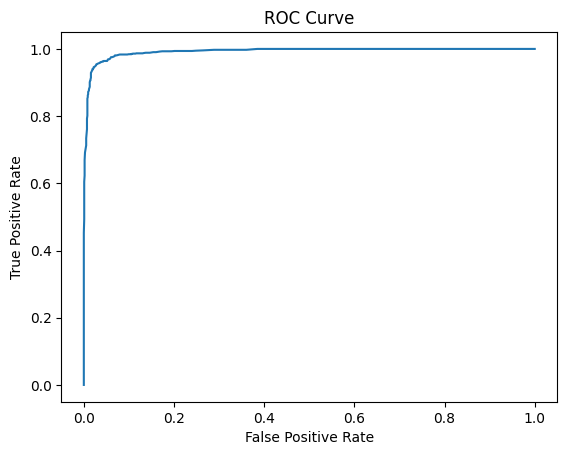

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [13]:
feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)


google_index           0.175315
page_rank              0.104422
nb_hyperlinks          0.085336
web_traffic            0.071273
nb_www                 0.038925
domain_age             0.033077
phish_hints            0.028756
ratio_extHyperlinks    0.028689
safe_anchor            0.028415
longest_word_path      0.026894
dtype: float64

In [14]:
joblib.dump(best_model, "phishing_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")


Model saved successfully!


In [15]:
model = joblib.load("phishing_model.pkl")
scaler = joblib.load("scaler.pkl")


In [19]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

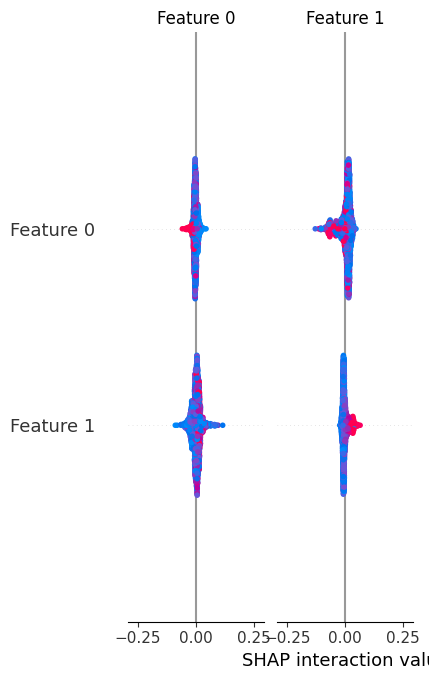

In [20]:
shap.summary_plot(shap_values, X_test)

In [28]:
X_scaled = scaler.fit_transform(X)

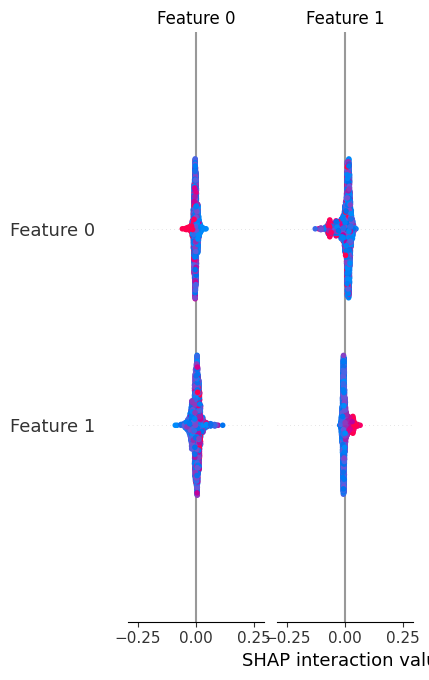

In [22]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [31]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
X_test.iloc[0]

length_url        -0.578947
length_hostname   -1.444444
ip                 0.000000
nb_dots           -1.000000
nb_hyphens         0.000000
                     ...   
domain_age        -0.659620
web_traffic        8.054791
dns_record         0.000000
google_index       0.000000
page_rank          0.250000
Name: 5151, Length: 87, dtype: float64